# Real World Classification

## Load data

Import the necessary libraries

In [1]:
# If you do not use colab. You should install these packages.
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn
# !pip install graphviz

In [3]:
!git clone https://github.com/fani8j/DM2026-Assignment-1.git
!mv DM2026-Assignment-1 assignment1
%cd /content/assignment1
!mkdir images
%matplotlib inline
# %reload_ext autoreload
# %autoreload 2

mv: cannot stat 'DM2026-Assignment-1': No such file or directory
/content/assignment1
mkdir: cannot create directory ‘images’: File exists


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

seed=40
np.random.seed(seed)

load the data

In [5]:
# Load data from the regularization demo CSV
df = pd.read_csv('data/NYCU_Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,7.0,NaN,4.700000,1.4,16.9,37.5,6.769877,6.755471,6.964281,...,0.466458,0.961982,-0.041964,-2.573335,-0.290155,1.346631,0.334072,0.303819,-1.318415,Iris-versicolor
1,2,6.4,3.2,4.500000,1.5,16.4,95.1,6.202714,6.129652,6.201464,...,-1.270085,1.283433,-1.155498,-0.295384,0.684086,-0.426519,0.113067,1.562539,0.095345,Iris-versicolor
2,3,6.9,NaN,4.900000,1.5,16.9,73.2,6.726317,6.762992,6.784647,...,0.562054,1.238704,0.345857,1.172525,0.320302,-0.563687,-1.514457,-0.179045,-0.577574,Iris-versicolor
3,4,5.5,2.3,5.085612,1.3,15.6,59.9,5.608292,5.529096,5.382254,...,-0.165898,0.914796,1.252364,-0.301381,-0.466333,-0.773040,-0.793858,0.483426,1.210299,Iris-versicolor
4,5,6.5,2.8,4.600000,1.5,16.4,15.6,6.300774,6.443553,6.274360,...,-0.602098,2.045948,-0.465691,0.862299,2.085633,2.047018,0.005283,0.506305,0.766709,Iris-versicolor


## Data Preprocessing

In [6]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafShadowIndex,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex
count,500.000000,472.000000,443.000000,350.000000,478.000000,476.000000,500.000000,500.000000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,6.320551,2.837472,5.085612,1.675732,16.302941,46.745800,6.316422,6.323365,6.320980,...,0.032051,0.068882,-0.029672,-0.015074,0.037059,0.082579,0.011686,0.077167,-0.034112,0.029674
std,144.481833,1.037115,0.389564,1.582807,0.706689,1.035228,30.032428,1.009859,1.043500,1.024075,...,0.962028,1.049557,1.046532,1.024190,0.995562,1.033822,1.011917,0.969005,0.949463,0.969047
min,1.000000,3.000000,1.500000,0.500000,-1.000000,12.700000,0.600000,2.877573,2.944078,2.955459,...,-2.885405,-3.258345,-3.090824,-2.673773,-2.735569,-3.033392,-2.625754,-3.143116,-2.878216,-2.589544
25%,125.750000,5.800000,2.600000,4.425000,1.300000,15.800000,18.500000,5.836615,5.801651,5.793089,...,-0.647824,-0.625022,-0.702388,-0.649046,-0.630572,-0.627218,-0.718793,-0.529432,-0.649448,-0.653394
50%,250.500000,6.300000,2.900000,5.085612,1.600000,16.300000,44.000000,6.316422,6.310315,6.320980,...,0.028643,0.076748,-0.047413,-0.044223,-0.022831,0.109614,-0.017135,0.112847,-0.019524,0.044542
75%,375.250000,6.700000,3.100000,5.500000,2.000000,16.800000,73.200000,6.738205,6.797044,6.699885,...,0.648784,0.806166,0.655584,0.641842,0.750853,0.816614,0.743847,0.751684,0.631034,0.674469
max,500.000000,9.600000,4.000000,9.200000,4.300000,19.700000,98.700000,10.032204,10.146460,10.262641,...,2.918638,3.333114,3.888629,3.174867,3.109433,3.507325,3.100138,2.626066,2.515151,3.254291


In [7]:
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer

def data_preprocessing(df):
    # transform label to bi-class
    df['Species'] = df['Species'].astype(str).str.strip()
    le = LabelEncoder()
    df['Species'] = le.fit_transform(df['Species'])

    feature_cols = [c for c in df.columns if c not in ['Id', 'Species']]

    # transform string to number
    for col in feature_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # TODO: Replace the missing values using “Nearest Neighbors Imputation”
    # ---------- Start your code below ----------
    imputer = KNNImputer()
    df[feature_cols] = imputer.fit_transform(df[feature_cols])
    # ---------- End your code above ----------

    # ---------- --------------------- ----------

    return df, feature_cols

df, feature_cols = data_preprocessing(df)

In [8]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,...,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.0000
mean,250.500000,6.319840,2.837040,5.049883,1.684440,16.303440,46.745800,6.316422,6.323365,6.320980,...,0.068882,-0.029672,-0.015074,0.037059,0.082579,0.011686,0.077167,-0.034112,0.029674,0.5200
std,144.481833,1.009275,0.372434,1.514955,0.694645,1.011012,30.032428,1.009859,1.043500,1.024075,...,1.049557,1.046532,1.024190,0.995562,1.033822,1.011917,0.969005,0.949463,0.969047,0.5001
min,1.000000,3.000000,1.500000,0.500000,-1.000000,12.700000,0.600000,2.877573,2.944078,2.955459,...,-3.258345,-3.090824,-2.673773,-2.735569,-3.033392,-2.625754,-3.143116,-2.878216,-2.589544,0.0000
25%,125.750000,5.800000,2.630000,4.500000,1.300000,15.800000,18.500000,5.836615,5.801651,5.793089,...,-0.625022,-0.702388,-0.649046,-0.630572,-0.627218,-0.718793,-0.529432,-0.649448,-0.653394,0.0000
50%,250.500000,6.300000,2.900000,5.035683,1.700000,16.300000,44.000000,6.316422,6.310315,6.320980,...,0.076748,-0.047413,-0.044223,-0.022831,0.109614,-0.017135,0.112847,-0.019524,0.044542,1.0000
75%,375.250000,6.700000,3.040000,5.300000,2.000000,16.700000,73.200000,6.738205,6.797044,6.699885,...,0.806166,0.655584,0.641842,0.750853,0.816614,0.743847,0.751684,0.631034,0.674469,1.0000
max,500.000000,9.600000,4.000000,9.200000,4.300000,19.700000,98.700000,10.032204,10.146460,10.262641,...,3.333114,3.888629,3.174867,3.109433,3.507325,3.100138,2.626066,2.515151,3.254291,1.0000


## Data Exploration

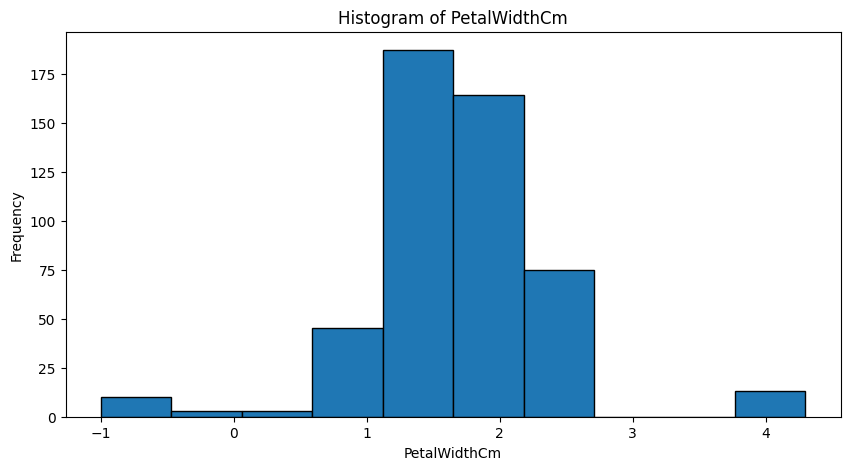

Largest positive correlation feature:
                  Feature  Pearson_r
26  PetalWidthCompactness   0.991670
25   PetalWidthElongation   0.991551
28    PetalWidthCurvature   0.991273
23    PetalWidthMajorAxis   0.991141
27       PetalWidthSpread   0.991095

Top 5 strongest negative correlations:
                  Feature  Pearson_r
11    SepalWidthMajorAxis  -0.096350
46        SepalGlossIndex  -0.095200
14  SepalWidthCompactness  -0.088496
16    SepalWidthCurvature  -0.081334
12    SepalWidthMinorAxis  -0.074392


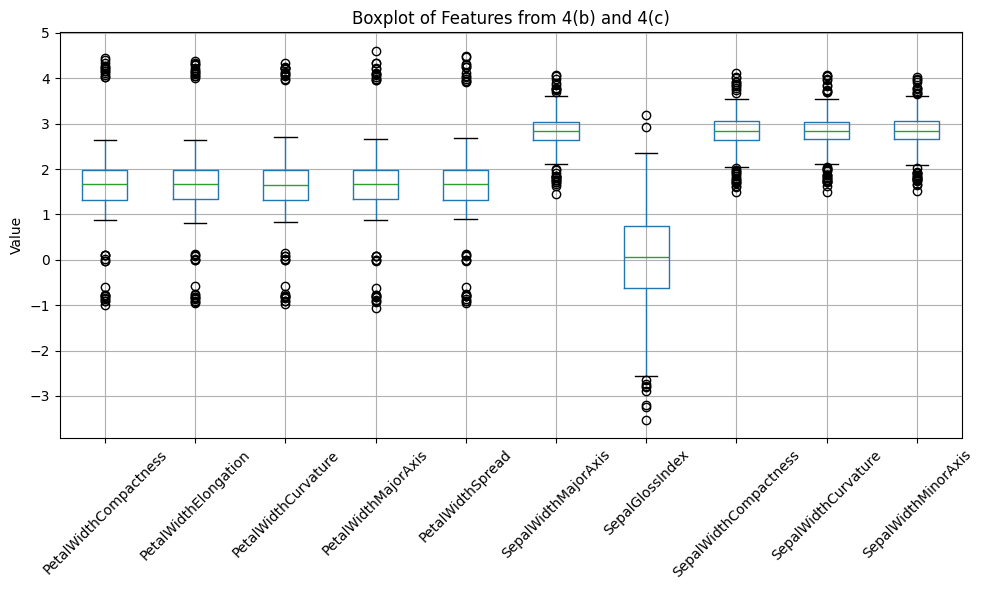

In [9]:
from sklearn.feature_selection import r_regression

# TODO: Complete the 4. Data Exploration
plt.figure(figsize=(10, 5))
plt.hist(df['PetalWidthCm'], edgecolor='black')
plt.xlabel('PetalWidthCm')
plt.ylabel('Frequency')
plt.title('Histogram of PetalWidthCm')
plt.show()

exclude_cols = ['PetalWidthCm', 'Species', 'Id']
feature_cols = [c for c in df.columns if c not in exclude_cols]

scores = r_regression(df[feature_cols], df['PetalWidthCm'])

corr_df = pd.DataFrame({
    'Feature': feature_cols,
    'Pearson_r': scores
})

# 4(b): largest positive correlation
top_positive_feature = corr_df.sort_values('Pearson_r', ascending=False).head(5)
print("Largest positive correlation feature:")
print(top_positive_feature)

# 4(c): top 5 strongest negative correlations
top5_negative = corr_df.sort_values('Pearson_r', ascending=True).head(5)
print("\nTop 5 strongest negative correlations:")
print(top5_negative)


selected_features = top_positive_feature['Feature'].tolist() + top5_negative['Feature'].tolist()

plt.figure(figsize=(10, 6))
df[selected_features].boxplot()
plt.title("Boxplot of Features from 4(b) and 4(c)")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Model Training

### Prepare the data

In [10]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

# normalize the data to [0,1]
for col in feature_cols:
    col_min = df[col].min()
    col_max = df[col].max()
    if col_max > col_min:
        df[col] = (df[col] - col_min) / (col_max - col_min)
    else:
        df[col] = 0.0

X = df[feature_cols].values.astype(float)
y = df['Species'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=seed)

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,BranchLength,AvgDust,SepalLengthMajorAxis,SepalLengthMinorAxis,SepalLengthElongation,...,LeafHueVariation,CanopyLightCapture,CanopyMoistureSignal,SoilMoistureSignal,AmbientHumiditySignal,ThermalResponseIndex,UVExposureIndex,WindStressIndex,GrowthVigorIndex,Species
0,1,0.606061,0.608,0.482759,1.4,0.600000,0.376147,0.544026,0.529185,0.548614,...,0.565095,0.580677,0.449986,0.027756,0.419409,0.693758,0.602718,0.589990,0.217516,0
1,2,0.515152,0.680,0.459770,1.5,0.528571,0.963303,0.464754,0.442295,0.444221,...,0.301642,0.626733,0.259595,0.417482,0.568359,0.384086,0.564410,0.823373,0.459439,0
2,3,0.590909,0.616,0.505747,1.5,0.600000,0.740061,0.537937,0.530229,0.524031,...,0.579598,0.620325,0.516296,0.668622,0.512741,0.360130,0.282303,0.500461,0.344289,0
3,4,0.378788,0.320,0.527082,1.3,0.414286,0.604485,0.381672,0.358911,0.332111,...,0.469160,0.573916,0.671291,0.416456,0.392474,0.323568,0.407208,0.623292,0.650231,0
4,5,0.530303,0.520,0.471264,1.5,0.528571,0.152905,0.478459,0.485877,0.454197,...,0.402983,0.735985,0.377538,0.615546,0.782640,0.816078,0.545727,0.627534,0.574324,0


### Train the model!

In [12]:
# Use the LinearModel to fit the data

from model.linear_model import LinearModel
from model.metrics import logloss
from model.gradients import logloss_sigmoid_grad
from model.utils import *
from model.activations import sigmoid
from sklearn.model_selection import cross_val_score, KFold

# Model configuration
loss_fn = logloss
act_fn = sigmoid
grad_fn = logloss_sigmoid_grad
data_path = 'images/'
np.random.seed(seed)

learning_rates = [0.005, 0.01, 0.1, 0.5]
reg_lambdas = [1.0, 2.0, 4.0, 8.0]

cv = KFold(n_splits=5, shuffle=True, random_state=40)
results = []

#OLD CODE
# r_ld = 100
# model = LinearModel(dim=X_train.shape[1], is_reg=False, loss_fn=loss_fn, act_fn=act_fn, grad_fn=grad_fn)
# model.fit(X_train, y_train,lr=0.1, n_iteration =10000,val_ratio=0.2, reg_type='l2', reg_lambda=r_ld,data_path=data_path+str(r_ld))

# print model parameters
# print("Model parameters (weights):", model.W)
# sum of absolute values of weights
# print("Sum of absolute values of weights:", np.sum(np.abs(model.W)))

for lr in learning_rates:
    for reg_lambda in reg_lambdas:
        np.random.seed(seed)

        model = LinearModel(
            dim=X_train.shape[1],
            is_reg=False,
            loss_fn=loss_fn,
            act_fn=act_fn,
            grad_fn=grad_fn,
            lr=lr,
            reg_type='l2',
            reg_lambda=reg_lambda,
            n_iteration=10000,
            val_ratio=0.2,
            random_state=seed,
            verbose=False,
            plot_curve=False
        )

        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=cv,
            scoring='accuracy'
        )
        print(f"Learning rate: {lr}, Regularization lambda: {reg_lambda}, Accuracy: {scores}")
        results.append({
            'learning_rate': lr,
            'reg_lambda': reg_lambda,
            'avg_accuracy': scores.mean()
        })

results_df = pd.DataFrame(results)
results_df

Learning rate: 0.005, Regularization lambda: 1.0, Accuracy: [0.7        0.72857143 0.77142857 0.65714286 0.8       ]
Learning rate: 0.005, Regularization lambda: 2.0, Accuracy: [0.7        0.74285714 0.74285714 0.65714286 0.8       ]
Learning rate: 0.005, Regularization lambda: 4.0, Accuracy: [0.74285714 0.74285714 0.71428571 0.65714286 0.78571429]
Learning rate: 0.005, Regularization lambda: 8.0, Accuracy: [0.74285714 0.71428571 0.68571429 0.68571429 0.72857143]
Learning rate: 0.01, Regularization lambda: 1.0, Accuracy: [0.7        0.77142857 0.77142857 0.62857143 0.78571429]
Learning rate: 0.01, Regularization lambda: 2.0, Accuracy: [0.71428571 0.75714286 0.74285714 0.62857143 0.78571429]
Learning rate: 0.01, Regularization lambda: 4.0, Accuracy: [0.74285714 0.74285714 0.68571429 0.64285714 0.77142857]
Learning rate: 0.01, Regularization lambda: 8.0, Accuracy: [0.74285714 0.72857143 0.68571429 0.7        0.72857143]
Learning rate: 0.1, Regularization lambda: 1.0, Accuracy: [0.7285714

,learning_rate,reg_lambda,avg_accuracy
0,0.005,1.0,0.731429
1,0.005,2.0,0.728571
2,0.005,4.0,0.728571
3,0.005,8.0,0.711429
4,0.010,1.0,0.731429
5,0.010,2.0,0.725714
6,0.010,4.0,0.717143
7,0.010,8.0,0.717143
8,0.100,1.0,0.725714
9,0.100,2.0,0.722857


In [13]:
cv_table = results_df.pivot_table(
    index='learning_rate',
    columns='reg_lambda',
    values='avg_accuracy',
    aggfunc='mean'
)
cv_table

reg_lambda,1.0,2.0,4.0,8.0
learning_rate,,,,
0.005,0.731429,0.728571,0.728571,0.711429
0.010,0.731429,0.725714,0.717143,0.717143
0.100,0.725714,0.722857,0.714286,0.717143
0.500,0.725714,0.705714,0.540000,0.468571


In [14]:
top2 = results_df.sort_values('avg_accuracy', ascending=False).head(2)
print(top2)

   learning_rate  reg_lambda  avg_accuracy
4          0.010         1.0      0.731429
0          0.005         1.0      0.731429


4

=== Testing top setting: lr=0.01, reg_lambda=1.0 ===
50. Training loss: 5.322994979601672, Val loss:5.695278447288146
100. Training loss: 3.949078390975787, Val loss:4.201859385600274
150. Training loss: 2.1017501654172657, Val loss:2.202841846311417
200. Training loss: 0.783911345626127, Val loss:0.7814232910655273
250. Training loss: 0.6284872453440532, Val loss:0.5975764376088771
300. Training loss: 0.6232242907598279, Val loss:0.5887013354765944
350. Training loss: 0.6205202405632634, Val loss:0.5866581717535373
400. Training loss: 0.6179298058151684, Val loss:0.5852072155853529
450. Training loss: 0.6154197978798148, Val loss:0.5838705097995168
500. Training loss: 0.612986530503519, Val loss:0.5825953439443363
550. Training loss: 0.6106267748089126, Val loss:0.581373641076225
600. Training loss: 0.6083374578970172, Val loss:0.5802023732965557
650. Training loss: 0.6061156580262509, Val loss:0.5790791858484378
700. Training loss: 0.603958597587826, Val loss:0.5780019034076039
75

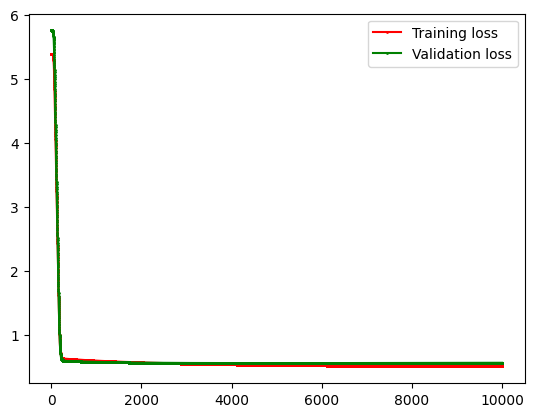

Test result: lr=0.01, reg_lambda=1.0
MSE       : 0.2533
MAE       : 0.2533
RMSE      : 0.5033
R-squared : -0.0135


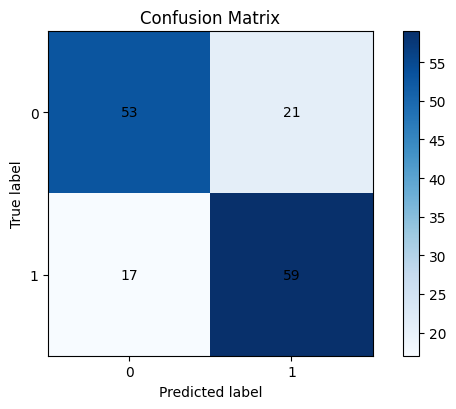

0

=== Testing top setting: lr=0.005, reg_lambda=1.0 ===
50. Training loss: 5.384609676726839, Val loss:5.752614576589204
100. Training loss: 5.319509189934612, Val loss:5.695285091309416
150. Training loss: 4.830402089820289, Val loss:5.177791654070748
200. Training loss: 3.930461570831486, Val loss:4.201936311314555
250. Training loss: 2.9987404304636507, Val loss:3.1933245542833464
300. Training loss: 2.0841969304841608, Val loss:2.2031667845445932
350. Training loss: 1.2667320884603779, Val loss:1.3171538017883626
400. Training loss: 0.7801926829282569, Val loss:0.783390813823215
450. Training loss: 0.6488744416635439, Val loss:0.6280098397717537
500. Training loss: 0.6284953722858286, Val loss:0.5978802065485316
550. Training loss: 0.6248310707278159, Val loss:0.5910573780880761
600. Training loss: 0.623202581041971, Val loss:0.58874189497934
650. Training loss: 0.6218264588183327, Val loss:0.5875365013420251
700. Training loss: 0.620497574285462, Val loss:0.586666710090727
750. T

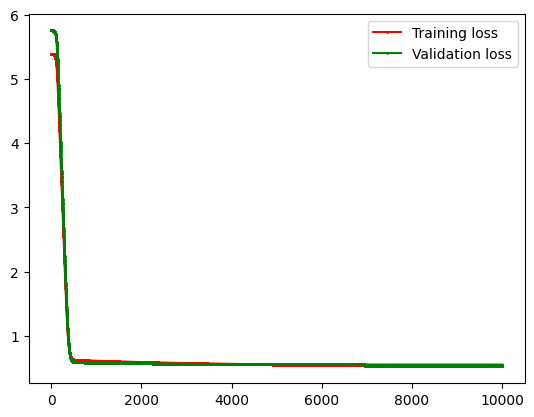

Test result: lr=0.005, reg_lambda=1.0
MSE       : 0.2333
MAE       : 0.2333
RMSE      : 0.4830
R-squared : 0.0665


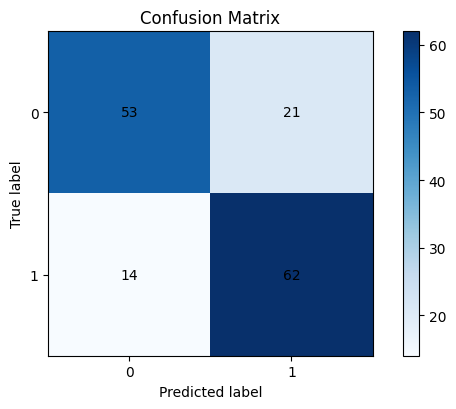

In [16]:
from model.metrics import evaluate_binary_classifier
for _, row in top2.iterrows():
    print(_)
    lr = row['learning_rate']
    reg_lambda = row['reg_lambda']

    print(f"\n=== Testing top setting: lr={lr}, reg_lambda={reg_lambda} ===")

    np.random.seed(seed)

    model = LinearModel(
        dim=X_train.shape[1],
        is_reg=False,
        loss_fn=loss_fn,
        act_fn=act_fn,
        grad_fn=grad_fn,
        lr=lr,
        reg_type='l2',
        reg_lambda=reg_lambda,
        n_iteration=10000,
        val_ratio=0.2,
        random_state=seed,
        verbose=True,
        plot_curve=True
    )

    model.fit(X_train, y_train,data_path=data_path+"ld"+str(reg_lambda)+"_lr"+str(lr))
    y_test_pred = model.predict(X_test)

    evaluate_binary_classifier(
        y_true=y_test,
        y_pred=y_test_pred,
        title=f"Test result: lr={lr}, reg_lambda={reg_lambda}",
        data_path=data_path+"ld"+str(reg_lambda)+"_lr"+str(lr)
    )

## Metrics

In [ ]:
#UNUSED

# use evaluate_binary_classifier to evaluate the model on the test set
# from model.metrics import evaluate_binary_classifier

# y_pred = model.predict(X_test)
# evaluate_binary_classifier(y_test, y_pred,data_path=data_path+str(r_ld))